In [2]:
from transformers import pipeline
from diffusers import AutoPipelineForInpainting, StableDiffusionInpaintPipeline
from PIL import Image as PILImageModule
from PIL.Image import Image
import numpy as np
import torch

/mnt/perma/bin/miniconda3/envs/depthedit/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
generator = torch.Generator(device=device).manual_seed(42)

sam_pipeline = pipeline("mask-generation", model="facebook/sam-vit-huge", device=device, generator=generator)

pipeline_inpaint = AutoPipelineForInpainting.from_pretrained(
    "weights/stable-diffusion-2-1-base",
    local_files_only=True,
    torch_dtype=torch.float16
)

# pipeline_inpaint = StableDiffusionInpaintPipeline.from_single_file(
#     "weights/sd-v1-5-inpainting.ckpt",
#     torch_dtype=torch.float16,
# )

pipeline_inpaint = pipeline_inpaint.to(device)
pipeline_inpaint.enable_model_cpu_offload()


Loading pipeline components...: 100%|██████████| 6/6 [00:01<00:00,  4.83it/s]


In [4]:
print(pipeline_inpaint.unet.config.in_channels)

9


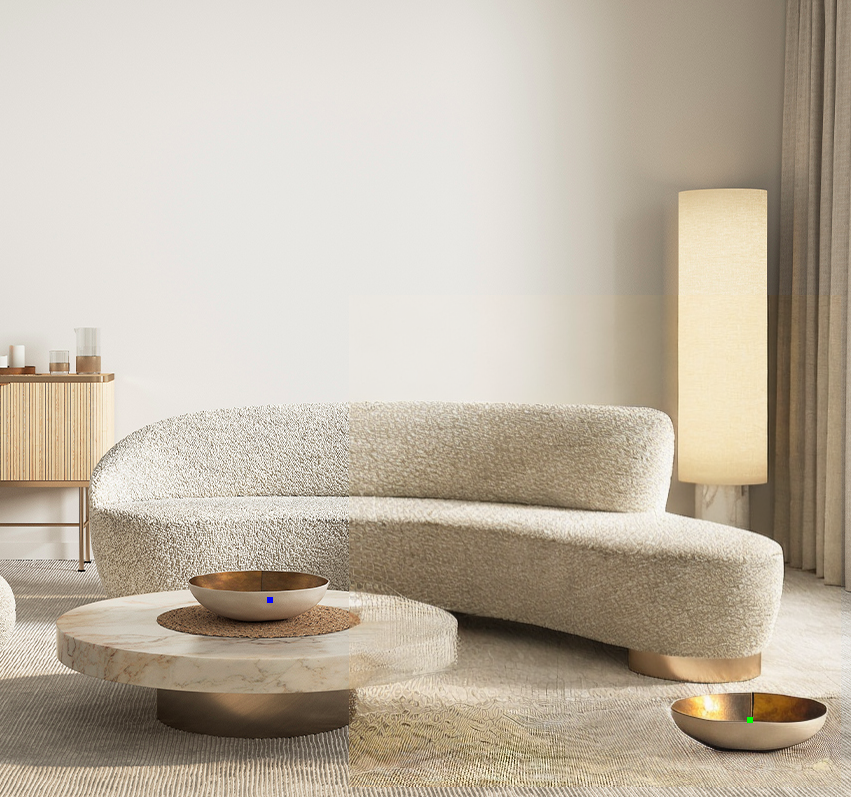

In [9]:
from utils.vis import draw_depth_pts
source_px = np.array([270, 600])
target_px = np.array([750, 720])
image_pil: Image = PILImageModule.open("results/new_object_placement/2025-11-19-21-34-41/0/result.png")
image = np.asarray(image_pil)
image_with_pts = draw_depth_pts(image, source_px, target_px)
PILImageModule.fromarray(image_with_pts).show()

In [10]:
from utils.img_proc import get_object_mask
import cv2

object_mask = get_object_mask(image, source_px, sam_pipeline)
object_mask_u8 = object_mask.astype(np.uint8)*255
dilate_kernel_size = 10
dilate_kernel = np.ones((dilate_kernel_size, dilate_kernel_size), np.uint8) 
object_mask_dilated = cv2.dilate(object_mask_u8, dilate_kernel, iterations=2)
object_mask_pil = PILImageModule.fromarray(object_mask_dilated, mode="L")


100%|██████████| 50/50 [00:10<00:00,  4.99it/s]


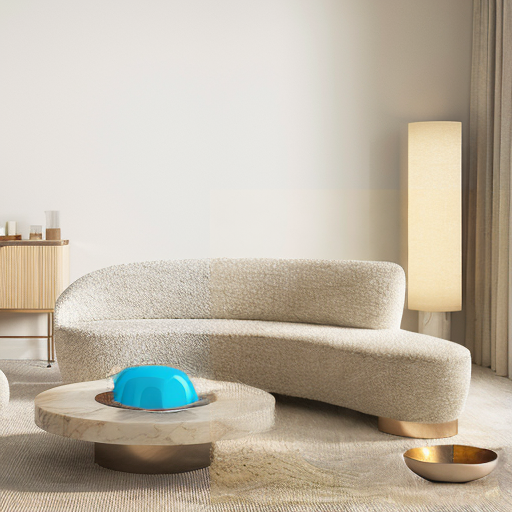

In [11]:
inpaint_pipe_size = (768,768)
inpainting_result = pipeline_inpaint(
    prompt="remove the object and paint a clear surface",
    image=image_pil.resize(inpaint_pipe_size),
    mask_image=object_mask_pil.resize(inpaint_pipe_size),
    generator=torch.Generator(device=device).manual_seed(42),
    device=device,
)
PILImageModule.fromarray(np.array(inpainting_result.images[0])).show()